# Regression

## About the Dataset


The Student Performance Dataset comprises 10,000 student records, each containing information about predictor variables and an academic performance index. The variables include:

* **Hours Studied**: total hours dedicated to studying.
* **Previous Scores**: scores on previously taken exams.
* **Extracurricular Activities**: participation (Yes or No).
* **Sleep Hours**: daily average hours of sleep.
* **Sample Question Papers Practiced**: number of practice questions/papers completed.

The target variable is the **Performance Index**, an integer value between 10 and 100 (higher is better), which summarizes the student's academic achievement. This dataset allows exploration of how each of these factors relates to overall performance.

source = [link](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression)

# Exploratory Analysis


https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression

In [ ]:
import kagglehub

path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

import os
os.listdir(path)
path = path + "/" + os.listdir(path)[0]

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

In [ ]:
students = pd.read_csv(path)
students.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


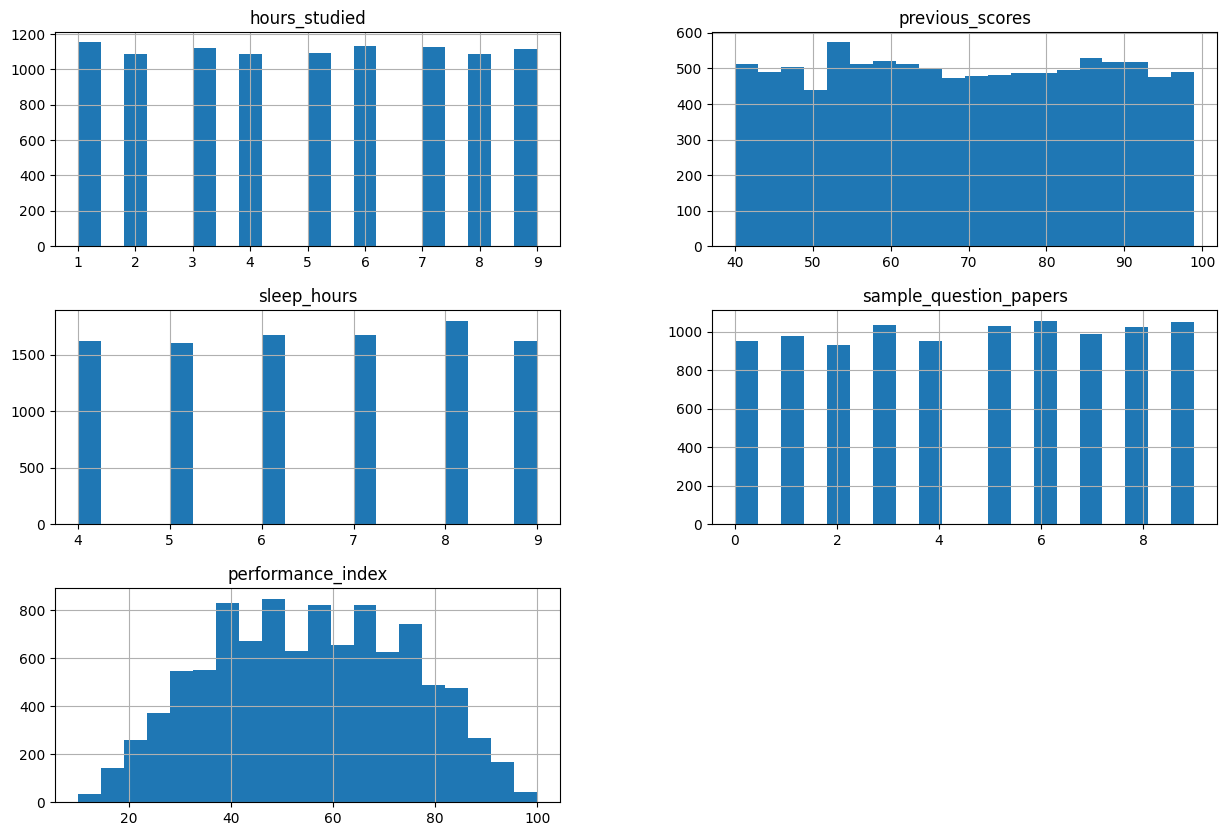

In [ ]:
students.columns = ['hours_studied', 'previous_scores', 'extracurricular', 'sleep_hours', 'sample_question_papers', 'performance_index']
students.hist(bins=20, figsize=(15,10));

In [ ]:
students.info()
students.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hours_studied           10000 non-null  int64  
 1   previous_scores         10000 non-null  int64  
 2   extracurricular         10000 non-null  object 
 3   sleep_hours             10000 non-null  int64  
 4   sample_question_papers  10000 non-null  int64  
 5   performance_index       10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


,hours_studied,previous_scores,sleep_hours,sample_question_papers,performance_index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
print(students.isna().sum())
print(students.isnull().sum())


hours_studied             0
previous_scores           0
extracurricular           0
sleep_hours               0
sample_question_papers    0
performance_index         0
dtype: int64
hours_studied             0
previous_scores           0
extracurricular           0
sleep_hours               0
sample_question_papers    0
performance_index         0
dtype: int64


In [ ]:
le = LabelEncoder()
students['extracurricular'] = le.fit_transform(students['extracurricular'])

In [ ]:
students.head()

,hours_studied,previous_scores,extracurricular,sleep_hours,sample_question_papers,performance_index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


<Axes: >

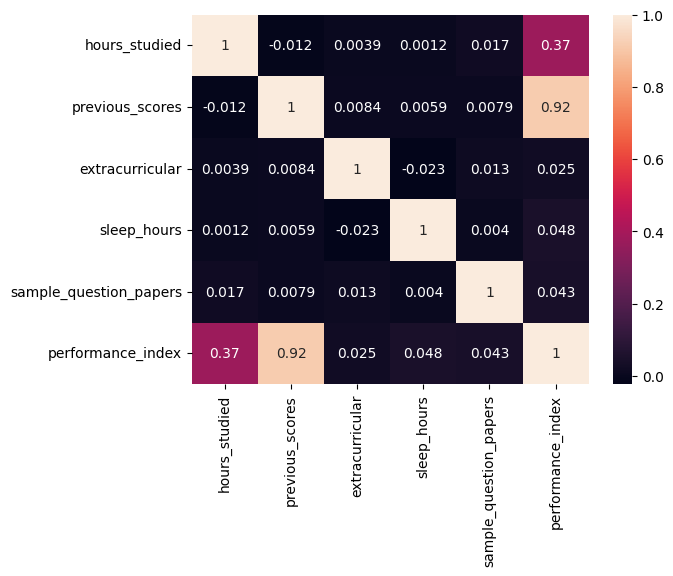

In [ ]:
import seaborn as sns

sns.heatmap(students.corr(), annot=True)

# SVR

In [ ]:
X = students.drop('performance_index', axis=1)
y = students['performance_index']


In [ ]:
X.shape, y.shape

((10000, 5), (10000,))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr.fit(X_train_scaled, y_train)

SVR()

In [ ]:
y_pred = svr.predict(X_test_scaled)


# Métricas
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = mse ** 0.5

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

MSE:  5.4206
RMSE: 2.3282
MAE:  1.8236
R²:   0.9854


## Cross-validation


In [ ]:
cv_mse = -cross_val_score(svr, X_train_scaled, y_train,
                          scoring='neg_mean_squared_error', cv=5)
cv_r2 = cross_val_score(svr, X_train_scaled, y_train,
                        scoring='r2', cv=5)

print(f"\nMSE médio CV: {cv_mse.mean():.4f} ± {cv_mse.std():.4f}")
print(f"R² médio CV:  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")


MSE médio CV: 5.8344 ± 0.1716
R² médio CV:  0.9842 ± 0.0005


## Optimization with GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Melhores parâmetros:", grid.best_params_)
print("Melhor MSE (CV):", -grid.best_score_)



Melhores parâmetros: {'C': 10, 'epsilon': 0.2, 'kernel': 'linear'}
Melhor MSE (CV): 4.180544510126451


In [ ]:
# Avaliaçao do melhor modelo
best_svr = grid.best_estimator_
y_pred = best_svr.predict(X_test_scaled)
print(f"R² teste: {r2_score(y_test, y_pred):.4f}")

R² teste: 0.9890


In [ ]:
for idx in [0, 5, 10, 15, 20]:
    amostra = X_test_scaled[idx].reshape(1, -1)
    real = y_test.iloc[idx]
    pred = best_svr.predict(amostra)[0]
    erro = abs(real - pred)

    print(f"Idx {idx}: Real={real:.2f}, Pred={pred:.2f}, Erro={erro:.2f}")

Idx 0: Real=51.00, Pred=54.70, Erro=3.70
Idx 5: Real=59.00, Pred=59.05, Erro=0.05
Idx 10: Real=66.00, Pred=63.56, Erro=2.44
Idx 15: Real=41.00, Pred=44.62, Erro=3.62
Idx 20: Real=59.00, Pred=62.43, Erro=3.43
